Extract & Inspect

Using zip: /content/archive (4).zip
Extracted to: /content/cats_dogs_dataset
Cat dirs found: ['/content/cats_dogs_dataset/animals/cat']
Dog dirs found: ['/content/cats_dogs_dataset/animals/dog']
Num cat images: 474
Num dog images: 500
Total images: 974
Corrupted cats: 0
Corrupted dogs: 0
Top cat sizes: [((512, 512), 474)]
Top dog sizes: [((512, 512), 500)]

Showing up to 3 cat samples and 3 dog samples...


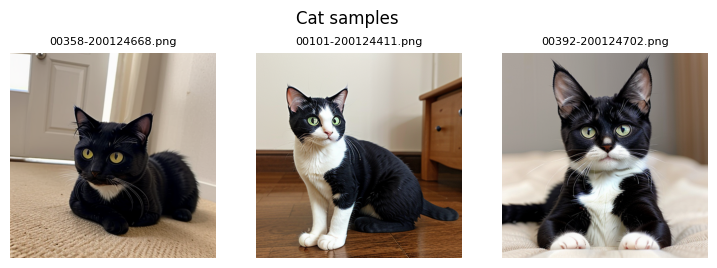

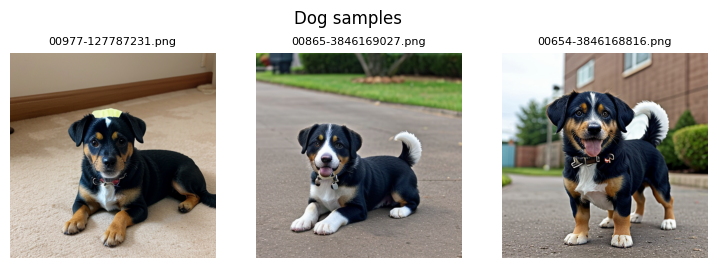


First 5 cat paths: ['/content/cats_dogs_dataset/animals/cat/00026-200124336.png', '/content/cats_dogs_dataset/animals/cat/00027-200124337.png', '/content/cats_dogs_dataset/animals/cat/00028-200124338.png', '/content/cats_dogs_dataset/animals/cat/00029-200124339.png', '/content/cats_dogs_dataset/animals/cat/00030-200124340.png']
First 5 dog paths: ['/content/cats_dogs_dataset/animals/dog/00500-3846168662.png', '/content/cats_dogs_dataset/animals/dog/00501-3846168663.png', '/content/cats_dogs_dataset/animals/dog/00502-3846168664.png', '/content/cats_dogs_dataset/animals/dog/00503-3846168665.png', '/content/cats_dogs_dataset/animals/dog/00504-3846168666.png']


In [ ]:
# Part 1: extract & inspect (Colab)
import os, zipfile, glob, random
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

# 1) try to find a .zip file in common locations
zip_candidates = glob.glob('/content/*.zip') + glob.glob('/mnt/data/*.zip') + glob.glob('/*.zip') + glob.glob('*.zip')
zip_path = zip_candidates[0] if zip_candidates else None

if not zip_path:
    raise FileNotFoundError("No .zip found in working dir. Upload the zip to Colab (e.g. /content) and re-run this cell.")

print("Using zip:", zip_path)

# 2) extract (if not already extracted)
extract_dir = '/content/cats_dogs_dataset'
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)
    print("Extracted to:", extract_dir)
else:
    print("Extraction folder already exists:", extract_dir)

# 3) find cat & dog folders (case-insensitive)
cat_dirs = []
dog_dirs = []
for root, dirs, files in os.walk(extract_dir):
    for d in dirs:
        dn = d.lower()
        if dn.startswith('cat') or 'cat' == dn:
            cat_dirs.append(os.path.join(root, d))
        if dn.startswith('dog') or 'dog' == dn:
            dog_dirs.append(os.path.join(root, d))

# if not found by name, try common structure: look for folders containing many filenames with 'cat' or 'dog' in filename
if not cat_dirs or not dog_dirs:
    all_files = glob.glob(os.path.join(extract_dir, '**', '*.*'), recursive=True)
    for f in all_files:
        name = os.path.basename(f).lower()
        if 'cat' in name and os.path.splitext(f)[1].lower() in ('.jpg','.jpeg','.png','.bmp'):
            cat_dirs.append(os.path.dirname(f))
        if 'dog' in name and os.path.splitext(f)[1].lower() in ('.jpg','.jpeg','.png','.bmp'):
            dog_dirs.append(os.path.dirname(f))
    cat_dirs = list(set(cat_dirs))
    dog_dirs = list(set(dog_dirs))

print("Cat dirs found:", cat_dirs)
print("Dog dirs found:", dog_dirs)

# 4) collect image file paths
def collect_imgs(dirs_list):
    img_paths = []
    for p in dirs_list:
        for ext in ('*.jpg','*.jpeg','*.png','*.bmp'):
            img_paths += glob.glob(os.path.join(p,ext))
    return sorted(list(set(img_paths)))

cat_paths = collect_imgs(cat_dirs)
dog_paths = collect_imgs(dog_dirs)

print("Num cat images:", len(cat_paths))
print("Num dog images:", len(dog_paths))
print("Total images:", len(cat_paths)+len(dog_paths))

# 5) check for corrupted images and gather sizes
def check_and_sizes(paths, max_report=10):
    corrupt = []
    sizes = []
    for p in paths:
        try:
            with Image.open(p) as im:
                im.verify()   # verify integrity
            with Image.open(p) as im:
                sizes.append(im.size)  # (width, height)
        except Exception as e:
            corrupt.append(p)
    if len(corrupt) > 0:
        print(f"Found {len(corrupt)} corrupted images (showing up to {max_report}):")
        for c in corrupt[:max_report]:
            print(" -", c)
    return corrupt, sizes

corrupt_cats, sizes_cats = check_and_sizes(cat_paths)
corrupt_dogs, sizes_dogs = check_and_sizes(dog_paths)

print("Corrupted cats:", len(corrupt_cats))
print("Corrupted dogs:", len(corrupt_dogs))
print("Top cat sizes:", Counter(sizes_cats).most_common(5))
print("Top dog sizes:", Counter(sizes_dogs).most_common(5))

# 6) display sample images (3 cats, 3 dogs)
def show_samples(paths, n=6, title='Samples'):
    if not paths:
        print("No images to show for", title)
        return
    samples = random.sample(paths, min(n, len(paths)))
    cols = 3
    rows = (len(samples) + cols - 1) // cols
    plt.figure(figsize=(cols*3, rows*3))
    for i, p in enumerate(samples):
        img = Image.open(p).convert('RGB')
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(os.path.basename(p), fontsize=8)
    plt.suptitle(title)
    plt.show()

print("\nShowing up to 3 cat samples and 3 dog samples...")
show_samples(cat_paths, n=3, title='Cat samples')
show_samples(dog_paths, n=3, title='Dog samples')

# 7) quick peek of first few file paths
print("\nFirst 5 cat paths:", cat_paths[:5])
print("First 5 dog paths:", dog_paths[:5])


In [ ]:
Split dataset into train/val/test

In [ ]:
# Part 2: Split dataset into train/val/test
import os, shutil, random

# Input folders (already found in Part-1)
cat_paths = cat_paths  # from previous step
dog_paths = dog_paths

# Output base directory
split_base = "/content/cats_dogs_split"
if os.path.exists(split_base):
    shutil.rmtree(split_base)
os.makedirs(split_base, exist_ok=True)

# Ratios
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15

def split_and_copy(img_paths, class_name):
    n = len(img_paths)
    random.shuffle(img_paths)
    train_end = int(train_ratio*n)
    val_end   = int((train_ratio+val_ratio)*n)

    subsets = {
        'train': img_paths[:train_end],
        'val':   img_paths[train_end:val_end],
        'test':  img_paths[val_end:]
    }

    for subset, paths in subsets.items():
        outdir = os.path.join(split_base, subset, class_name)
        os.makedirs(outdir, exist_ok=True)
        for p in paths:
            shutil.copy(p, outdir)

split_and_copy(cat_paths, "cat")
split_and_copy(dog_paths, "dog")

# Verify counts
for subset in ['train','val','test']:
    c = len(os.listdir(os.path.join(split_base, subset, "cat")))
    d = len(os.listdir(os.path.join(split_base, subset, "dog")))
    print(f"{subset}: cats={c}, dogs={d}, total={c+d}")


train: cats=331, dogs=350, total=681
val: cats=71, dogs=75, total=146
test: cats=72, dogs=75, total=147


Data Generators (Preprocessing)

In [ ]:
# Part 3: Data Generators (Preprocessing)
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path where Part-2 stored split data
split_base = "/content/cats_dogs_split"

# Image size (for CNN input)
img_size = (128, 128)
batch_size = 32

# Train generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation / test generator (no augmentation, only rescale)
test_val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(split_base, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

val_gen = test_val_datagen.flow_from_directory(
    os.path.join(split_base, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

test_gen = test_val_datagen.flow_from_directory(
    os.path.join(split_base, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)


Found 681 images belonging to 2 classes.
Found 146 images belonging to 2 classes.
Found 147 images belonging to 2 classes.
Class indices: {'cat': 0, 'dog': 1}


Visualizations

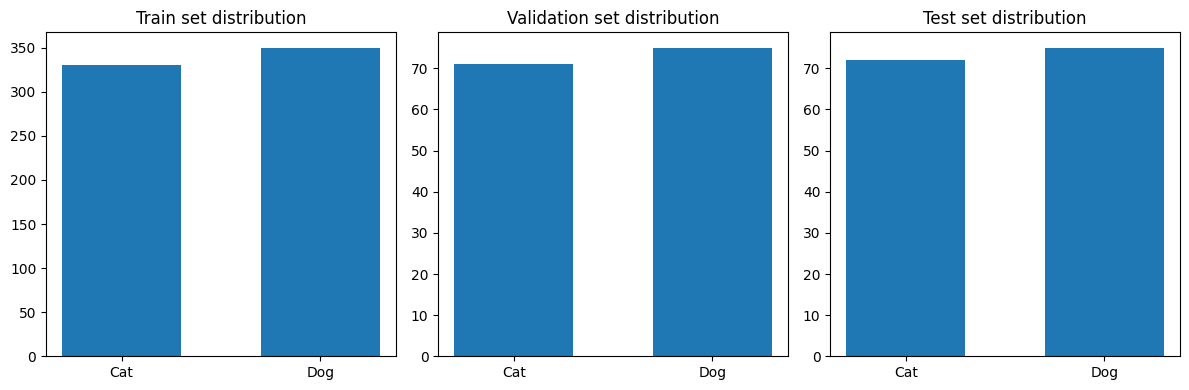

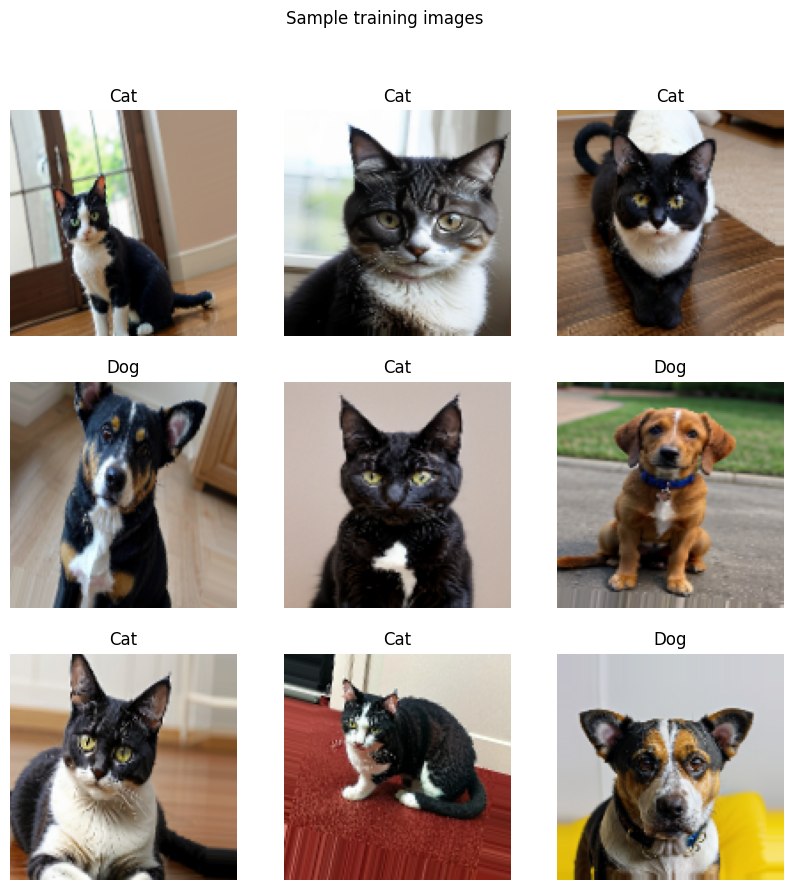

In [ ]:
# Part 3.1: Visualizations
import matplotlib.pyplot as plt
import numpy as np

# Count class distribution from generators
train_counts = train_gen.classes
val_counts = val_gen.classes
test_counts = test_gen.classes

# Plot class distribution
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(train_counts, bins=np.arange(3)-0.5, rwidth=0.6)
plt.xticks([0,1], ['Cat','Dog'])
plt.title("Train set distribution")

plt.subplot(1,3,2)
plt.hist(val_counts, bins=np.arange(3)-0.5, rwidth=0.6)
plt.xticks([0,1], ['Cat','Dog'])
plt.title("Validation set distribution")

plt.subplot(1,3,3)
plt.hist(test_counts, bins=np.arange(3)-0.5, rwidth=0.6)
plt.xticks([0,1], ['Cat','Dog'])
plt.title("Test set distribution")

plt.tight_layout()
plt.show()

# Show some sample training images
sample_imgs, sample_labels = next(train_gen)  # one batch
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(sample_imgs[i])
    plt.title("Dog" if sample_labels[i]==1 else "Cat")
    plt.axis("off")
plt.suptitle("Sample training images")
plt.show()


CNN

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.5186 - loss: 0.7067 - val_accuracy: 0.8288 - val_loss: 0.5422
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6878 - loss: 0.5933 - val_accuracy: 0.9041 - val_loss: 0.3682
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8302 - loss: 0.4209 - val_accuracy: 0.9110 - val_loss: 0.2835
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8470 - loss: 0.3623 - val_accuracy: 0.9521 - val_loss: 0.1801
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9107 - loss: 0.2325 - val_accuracy: 0.9589 - val_loss: 0.1127
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9246 - loss: 0.2199 - val_accuracy: 0.9795 - val_loss: 0.0772
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9266 - loss: 0.1959 - val_accuracy: 0.9795 - val_loss: 0.0691
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9482 - loss: 0.1324 - val_accuracy: 0.9863 - val_loss:

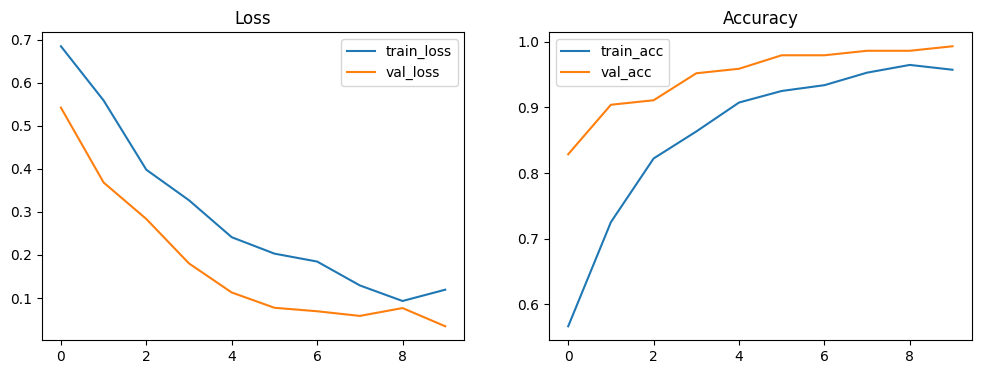

In [ ]:
# Part 4: Model 1 - Simple CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build model
model1 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # binary classification
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model1.summary()

# Train the model
history1 = model1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

# Evaluate on test set
test_loss, test_acc = model1.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history1.history['loss'], label='train_loss')
plt.plot(history1.history['val_loss'], label='val_loss')
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history1.history['accuracy'], label='train_acc')
plt.plot(history1.history['val_accuracy'], label='val_acc')
plt.title("Accuracy")
plt.legend()
plt.show()




5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 750ms/step
Classification Report:
              precision    recall  f1-score   support

         Cat       0.97      0.97      0.97        72
         Dog       0.97      0.97      0.97        75

    accuracy                           0.97       147
   macro avg       0.97      0.97      0.97       147
weighted avg       0.97      0.97      0.97       147



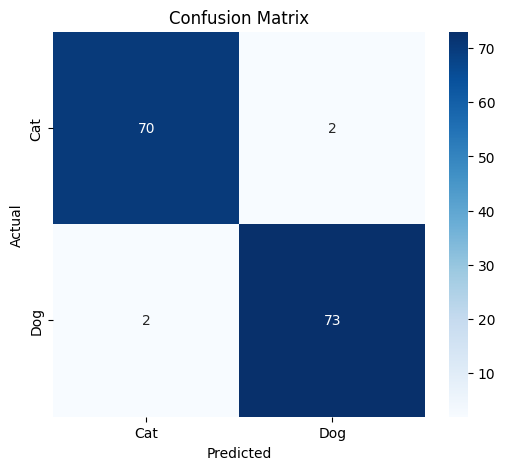

In [ ]:
# Part 4.2: Classification Report & Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Get predictions on test set
test_gen.reset()  # ensure correct order
pred_probs = model1.predict(test_gen)
pred_labels = (pred_probs > 0.5).astype(int).reshape(-1)

# True labels
true_labels = test_gen.classes

# Classification report
print("Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=['Cat','Dog']))

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat','Dog'], yticklabels=['Cat','Dog'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


VGG16 Transfer Learning

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 183s 8s/step - accuracy: 0.5676 - loss: 0.7120 - val_accuracy: 0.7945 - val_loss: 0.5675
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 174s 8s/step - accuracy: 0.6391 - loss: 0.6422 - val_accuracy: 0.9384 - val_loss: 0.4832
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 167s 8s/step - accuracy: 0.7161 - loss: 0.5601 - val_accuracy: 0.9521 - val_loss: 0.4194
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 168s 8s/step - accuracy: 0.7348 - loss: 0.5282 - val_accuracy: 0.9521 - val_loss: 0.3674
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 173s 8s/step - accuracy: 0.8118 - loss: 0.4619 - val_accuracy: 0.9521 - val_loss: 0.3240
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 197s 8s/step - accuracy: 0.8284 - loss: 0.4334 - val_accuracy: 0.9589 - val_loss: 0.2903
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 167s 8s/step - accuracy: 0.8798 - loss: 0.3813 - val_accuracy: 0.9589 - val_loss: 0.2625
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 168s 8s/step - accuracy: 0.8854 - loss: 0.3445 - val_accuracy: 0.9589 - v

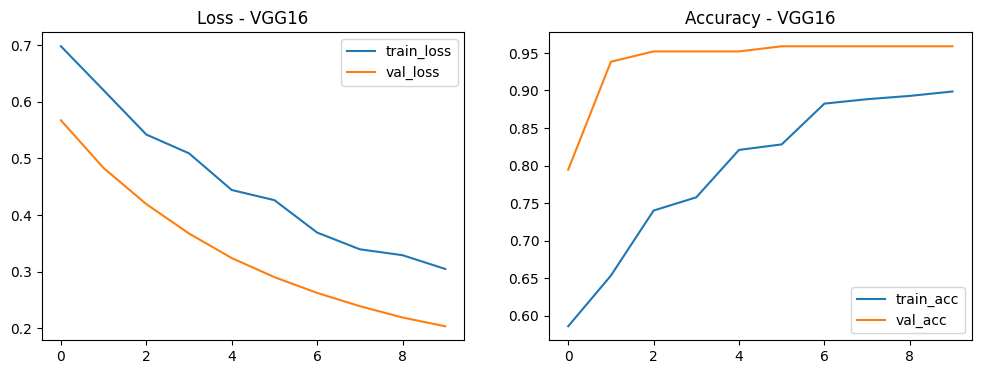

4/5 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step 

In [ ]:
# Part 5: Model 2 - VGG16 Transfer Learning
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load VGG16 base (without top)
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))
vgg_base.trainable = False  # freeze base layers

# Build top classifier
model2 = Sequential([
    vgg_base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model2.summary()

# Train model
history2 = model2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

# Evaluate on test set
test_loss2, test_acc2 = model2.evaluate(test_gen)
print(f"VGG16 Test Accuracy: {test_acc2*100:.2f}%")

# Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history2.history['loss'], label='train_loss')
plt.plot(history2.history['val_loss'], label='val_loss')
plt.title("Loss - VGG16")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history2.history['accuracy'], label='train_acc')
plt.plot(history2.history['val_accuracy'], label='val_acc')
plt.title("Accuracy - VGG16")
plt.legend()
plt.show()


5/5 ━━━━━━━━━━━━━━━━━━━━ 32s 6s/step
VGG16 Classification Report:
              precision    recall  f1-score   support

         Cat       0.92      1.00      0.96        72
         Dog       1.00      0.92      0.96        75

    accuracy                           0.96       147
   macro avg       0.96      0.96      0.96       147
weighted avg       0.96      0.96      0.96       147



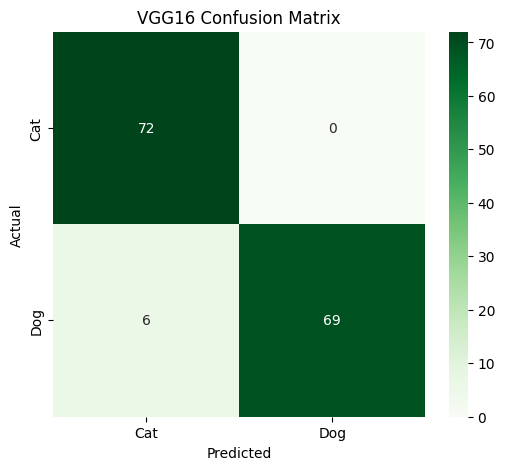

In [ ]:
# Classification report & confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_gen.reset()
pred_probs2 = model2.predict(test_gen)
pred_labels2 = (pred_probs2 > 0.5).astype(int).reshape(-1)
true_labels = test_gen.classes

print("VGG16 Classification Report:")
print(classification_report(true_labels, pred_labels2, target_names=['Cat','Dog']))

cm2 = confusion_matrix(true_labels, pred_labels2)
plt.figure(figsize=(6,5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', xticklabels=['Cat','Dog'], yticklabels=['Cat','Dog'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VGG16 Confusion Matrix")
plt.show()

ResNet50 Transfer Learning

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.5239 - loss: 0.7530 - val_accuracy: 0.6164 - val_loss: 0.6893
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.5003 - loss: 0.7339 - val_accuracy: 0.5137 - val_loss: 0.6886
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.4930 - loss: 0.7401 - val_accuracy: 0.5137 - val_loss: 0.6858
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.4849 - loss: 0.7362 - val_accuracy: 0.5753 - val_loss: 0.6841
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.5279 - loss: 0.7100 - val_accuracy: 0.5205 - val_loss: 0.6829
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.2926 - loss: 0.7033
ResNet50 Test Accuracy: 51.70%


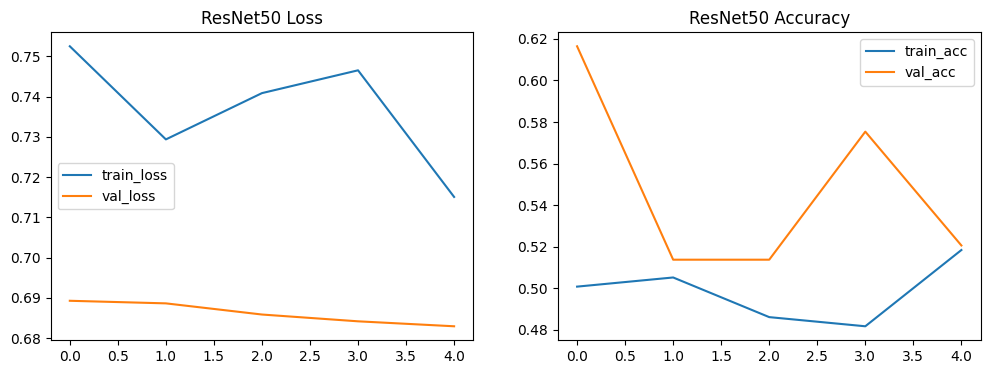

In [ ]:
# Part 6: Model 3 - ResNet50 Transfer Learning
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load ResNet50 base (pretrained on ImageNet)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128,128,3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom top layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
preds = Dense(1, activation='sigmoid')(x)

model3 = Model(inputs=base_model.input, outputs=preds)
model3.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model3.summary()

# Train the model (keep epochs small to save time)
history3 = model3.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5  # 5-10 epochs usually enough for transfer learning
)

# Evaluate on test set
test_loss3, test_acc3 = model3.evaluate(test_gen)
print(f"ResNet50 Test Accuracy: {test_acc3*100:.2f}%")

# Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history3.history['loss'], label='train_loss')
plt.plot(history3.history['val_loss'], label='val_loss')
plt.title("ResNet50 Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history3.history['accuracy'], label='train_acc')
plt.plot(history3.history['val_accuracy'], label='val_acc')
plt.title("ResNet50 Accuracy")
plt.legend()
plt.show()




5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
ResNet50 Classification Report:
              precision    recall  f1-score   support

         Cat       1.00      0.01      0.03        72
         Dog       0.51      1.00      0.68        75

    accuracy                           0.52       147
   macro avg       0.76      0.51      0.35       147
weighted avg       0.75      0.52      0.36       147



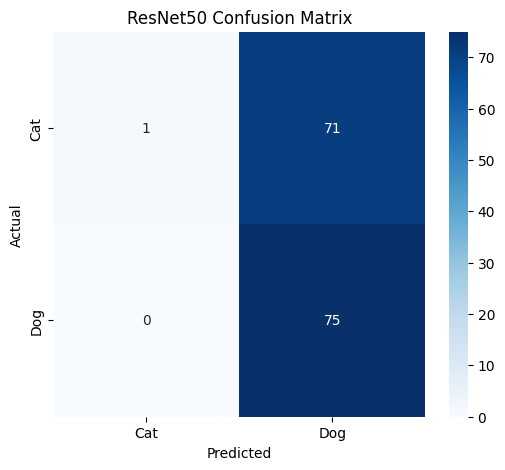

In [ ]:
# Part 6.1: Classification report & confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_gen.reset()
pred_probs3 = model3.predict(test_gen)
pred_labels3 = (pred_probs3>0.5).astype(int).reshape(-1)
true_labels = test_gen.classes

print("ResNet50 Classification Report:")
print(classification_report(true_labels, pred_labels3, target_names=['Cat','Dog']))

cm3 = confusion_matrix(true_labels, pred_labels3)
plt.figure(figsize=(6,5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat','Dog'], yticklabels=['Cat','Dog'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")
plt.show()

MobileNetV2 Transfer Learning

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7100 - loss: 0.5719 - val_accuracy: 0.9863 - val_loss: 0.0999
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 977ms/step - accuracy: 0.9606 - loss: 0.1295 - val_accuracy: 0.9932 - val_loss: 0.0367
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 990ms/step - accuracy: 0.9956 - loss: 0.0515 - val_accuracy: 1.0000 - val_loss: 0.0223
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 935ms/step - accuracy: 0.9957 - loss: 0.0440 - val_accuracy: 1.0000 - val_loss: 0.0152
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 991ms/step - accuracy: 0.9894 - loss: 0.0454 - val_accuracy: 1.0000 - val_loss: 0.0114
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 498ms/step - accuracy: 1.0000 - loss: 0.0104
MobileNetV2 Test Accuracy: 100.00%


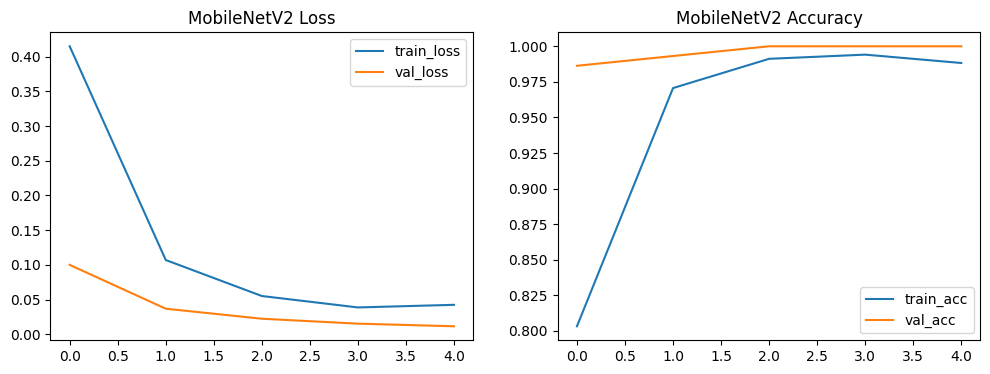

In [ ]:
# Part 7: Model 4 - MobileNetV2 Transfer Learning
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load MobileNetV2 base (pretrained on ImageNet)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128,128,3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom top layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
preds = Dense(1, activation='sigmoid')(x)

model4 = Model(inputs=base_model.input, outputs=preds)
model4.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model4.summary()

# Train the model (short epochs for speed)
history4 = model4.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

# Evaluate on test set
test_loss4, test_acc4 = model4.evaluate(test_gen)
print(f"MobileNetV2 Test Accuracy: {test_acc4*100:.2f}%")

# Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history4.history['loss'], label='train_loss')
plt.plot(history4.history['val_loss'], label='val_loss')
plt.title("MobileNetV2 Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history4.history['accuracy'], label='train_acc')
plt.plot(history4.history['val_accuracy'], label='val_acc')
plt.title("MobileNetV2 Accuracy")
plt.legend()
plt.show()


5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 944ms/step
MobileNetV2 Classification Report:
              precision    recall  f1-score   support

         Cat       1.00      1.00      1.00        72
         Dog       1.00      1.00      1.00        75

    accuracy                           1.00       147
   macro avg       1.00      1.00      1.00       147
weighted avg       1.00      1.00      1.00       147



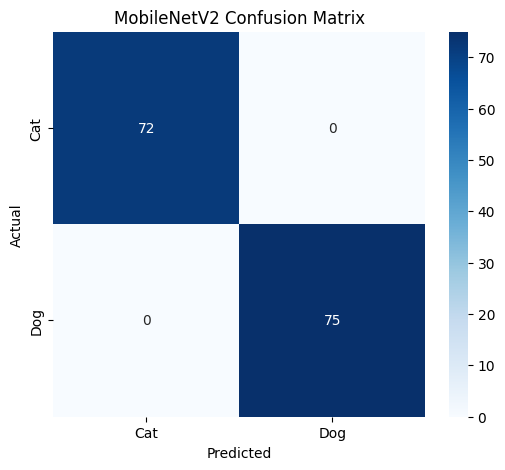

In [ ]:
# Classification report & confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_gen.reset()
pred_probs4 = model4.predict(test_gen)
pred_labels4 = (pred_probs4>0.5).astype(int).reshape(-1)
true_labels = test_gen.classes

print("MobileNetV2 Classification Report:")
print(classification_report(true_labels, pred_labels4, target_names=['Cat','Dog']))

cm4 = confusion_matrix(true_labels, pred_labels4)
plt.figure(figsize=(6,5))
sns.heatmap(cm4, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat','Dog'], yticklabels=['Cat','Dog'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

EfficientNetB0 Transfer Learning

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 128, 128,  │          0 │ input_layer_8[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 128, 128,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 128, 128,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 129, 129,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 64, 64,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 64, 64,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 64, 64,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 64, 64,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 64,    │        512 │ block1a_se_excit

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.4768 - loss: 0.7076 - val_accuracy: 0.5137 - val_loss: 0.6926
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.5011 - loss: 0.6994 - val_accuracy: 0.5137 - val_loss: 0.6926
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.4704 - loss: 0.7042 - val_accuracy: 0.5137 - val_loss: 0.6932
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.4857 - loss: 0.7044 - val_accuracy: 0.5137 - val_loss: 0.6927
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.4846 - loss: 0.7013 - val_accuracy: 0.5137 - val_loss: 0.6927
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 747ms/step - accuracy: 0.2847 - loss: 0.7146
EfficientNetB0 Test Accuracy: 51.02%


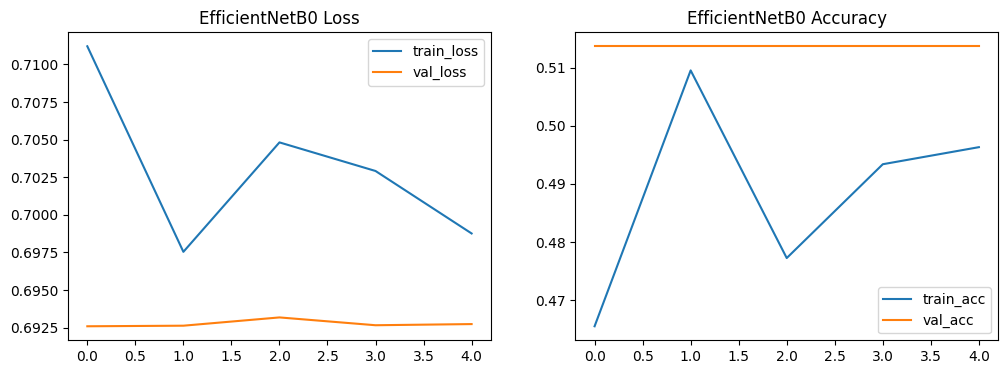

In [ ]:
# Part 8: Model 5 - EfficientNetB0 Transfer Learning
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load EfficientNetB0 base (pretrained on ImageNet)
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128,128,3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom top layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
preds = Dense(1, activation='sigmoid')(x)

model5 = Model(inputs=base_model.input, outputs=preds)
model5.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model5.summary()

# Train the model (short epochs)
history5 = model5.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

# Evaluate on test set
test_loss5, test_acc5 = model5.evaluate(test_gen)
print(f"EfficientNetB0 Test Accuracy: {test_acc5*100:.2f}%")

# Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history5.history['loss'], label='train_loss')
plt.plot(history5.history['val_loss'], label='val_loss')
plt.title("EfficientNetB0 Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history5.history['accuracy'], label='train_acc')
plt.plot(history5.history['val_accuracy'], label='val_acc')
plt.title("EfficientNetB0 Accuracy")
plt.legend()
plt.show()



4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
EfficientNetB0 Classification Report:
              precision    recall  f1-score   support

         Cat       0.00      0.00      0.00        72
         Dog       0.51      1.00      0.68        75

    accuracy                           0.51       147
   macro avg       0.26      0.50      0.34       147
weighted avg       0.26      0.51      0.34       147



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


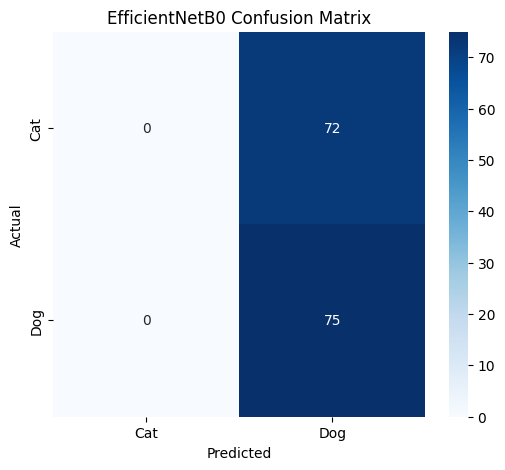

In [ ]:
# Classification report & confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_gen.reset()
pred_probs5 = model5.predict(test_gen)
pred_labels5 = (pred_probs5>0.5).astype(int).reshape(-1)
true_labels = test_gen.classes

print("EfficientNetB0 Classification Report:")
print(classification_report(true_labels, pred_labels5, target_names=['Cat','Dog']))

cm5 = confusion_matrix(true_labels, pred_labels5)
plt.figure(figsize=(6,5))
sns.heatmap(cm5, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat','Dog'], yticklabels=['Cat','Dog'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()


User input

Saving img1.jpeg to img1 (2).jpeg

Predictions for img1 (2).jpeg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Simple CNN: Cat (probability=0.3442)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
VGG16: Cat (probability=0.1768)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
ResNet50: Dog (probability=0.5139)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
MobileNetV2: Cat (probability=0.0182)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
EfficientNetB0: Dog (probability=0.5234)


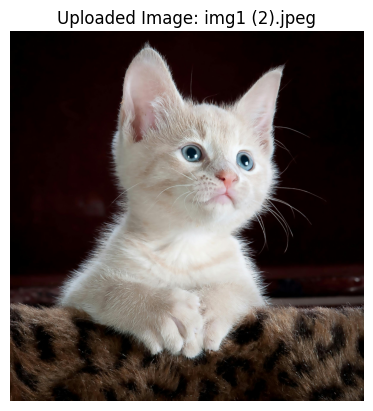

Upload another image? (y/n): y


Saving img2.jpg to img2 (2).jpg

Predictions for img2 (2).jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Simple CNN: Dog (probability=0.7374)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
VGG16: Dog (probability=0.5300)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
ResNet50: Dog (probability=0.5043)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
MobileNetV2: Dog (probability=0.8007)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
EfficientNetB0: Dog (probability=0.5226)


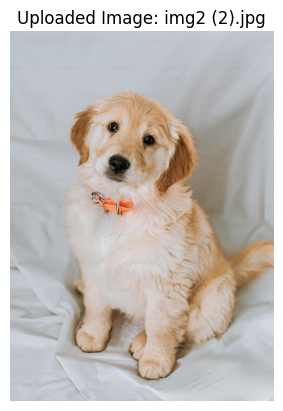

Upload another image? (y/n): y


Saving img3.jpg to img3 (2).jpg

Predictions for img3 (2).jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Simple CNN: Dog (probability=0.5928)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
VGG16: Dog (probability=0.5531)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
ResNet50: Cat (probability=0.4971)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
MobileNetV2: Cat (probability=0.0044)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
EfficientNetB0: Dog (probability=0.5225)


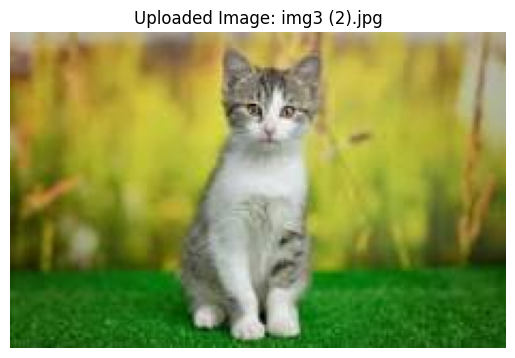

Upload another image? (y/n): y


Saving img4.jpg to img4 (2).jpg

Predictions for img4 (2).jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Simple CNN: Dog (probability=0.9699)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
VGG16: Dog (probability=0.6704)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
ResNet50: Dog (probability=0.5056)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
MobileNetV2: Dog (probability=0.7655)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
EfficientNetB0: Dog (probability=0.5230)


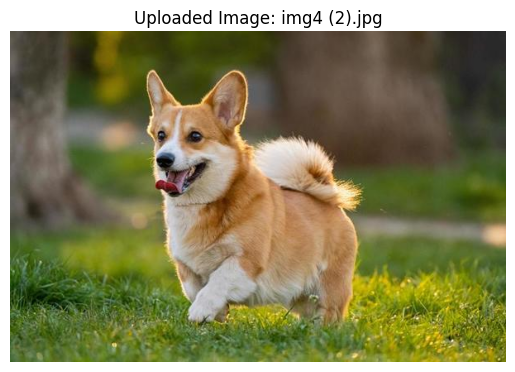

Upload another image? (y/n): n


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

def preprocess_input_img(img_path):
    img = image.load_img(img_path, target_size=(128,128))
    x = image.img_to_array(img)/255.0
    x = np.expand_dims(x, axis=0)
    return x

def predict_model(model, x):
    pred = model.predict(x)[0][0]
    label = "Dog" if pred>0.5 else "Cat"
    return pred, label

models_dict = {
    "Simple CNN": model1,
    "VGG16": model2,
    "ResNet50": model3,
    "MobileNetV2": model4,
    "EfficientNetB0": model5
}

while True:
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]
    x = preprocess_input_img(img_path)

    print(f"\nPredictions for {img_path}:")
    for name, model in models_dict.items():
        pred_prob, pred_label = predict_model(model, x)
        print(f"{name}: {pred_label} (probability={pred_prob:.4f})")

    # Show image
    plt.imshow(image.load_img(img_path))
    plt.axis("off")
    plt.title(f"Uploaded Image: {img_path}")
    plt.show()

    cont = input("Upload another image? (y/n): ")
    if cont.lower() != 'y':
        break
